# Customer Churn Prediction — EDA

Telco Customer Churn dataset (7043 rows, 21 columns).

## 1. Initial observations
- No missing values (all columns: 7043 non-null)
- `TotalCharges` is `object` type — should be numeric, needs investigation
- 18 categorical columns require encoding before modeling
- `customerID` is unique per row — drop before training
- Target column: `Churn` (Yes/No)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb


print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)
print("Everything is working!")

pandas: 3.0.2
numpy: 2.4.4
scikit-learn: 1.8.0
xgboost: 3.2.0
Everything is working!


In [4]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Basic info
print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}, Rows: {df.shape[0]}")

Shape: (7043, 21)
Columns: 21, Rows: 7043


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Descriptive Statistics & Missing Values

In [7]:
# Descriptive statistics for numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Key observations from descriptive statistics:

- **tenure** ranges from 0 to 72 months (~6 years). Median is 29 months.
- **MonthlyCharges** range from $18 to $119, with a wide spread (std=$30).
- **SeniorCitizen** is a binary flag (0/1), with ~16% of customers being seniors.
- **tenure = 0** suggests we have brand-new customers in the dataset.
- **TotalCharges** is missing from `describe()` output - it's currently stored 
  as `object` (string) instead of numeric. 

## 3. Fixing TotalCharges Data Type

`TotalCharges` should be numeric (it's a sum of payments), but `df.info()` 
showed it as `object`.

In [8]:
# Check the data type and a sample
print("Current dtype:", df['TotalCharges'].dtype)
print("\nFirst 5 values:")
print(df['TotalCharges'].head())
print("\nAre there any non-numeric strings?")
# Try converting to numeric, force errors to NaN
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Rows that couldn't be converted: {total_charges_numeric.isna().sum()}")

Current dtype: str

First 5 values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

Are there any non-numeric strings?
Rows that couldn't be converted: 11


### Investigating the 11 non-convertible rows

In [9]:
# Find rows where TotalCharges can't be converted to numeric
non_numeric_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
df[non_numeric_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Fix and verify

All 11 problematic rows have `tenure=0` - these are brand-new customers who 
haven't been billed yet. Let's convert `TotalCharges` to numeric, replacing 
empty strings with `0` (they've paid $0 so far, which is mathematically correct).

In [10]:
# Convert TotalCharges to numeric, replacing empty strings with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Verify the fix
print("New dtype:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isna().sum())
print(f"\nDescriptive stats for TotalCharges:")
print(df['TotalCharges'].describe())

New dtype: float64
Missing values: 0

Descriptive stats for TotalCharges:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


## 4. Target Variable: Class Balance

In churn prediction, **class imbalance** matters a lot. If 95% of customers 
don't churn, a "always predict No" model would get 95% accuracy but be useless. 

Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


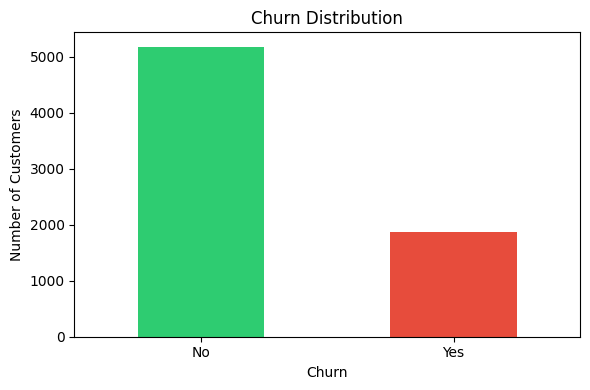

In [11]:
# Check churn distribution

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_pct.round(2))

# Quick visualization
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

### Class balance findings

- **No churn**: 5174 customers (73.46%)
- **Churn**: 1869 customers (26.54%)

The dataset shows **mild class imbalance**. This means:
- Accuracy alone is misleading - a "always predict No" baseline would score 73%.
- We'll use **F1-score** and **ROC-AUC** as primary metrics.
- **Recall** is especially important: missing a churn (false negative) is more 
  costly than a false alarm - a lost customer means lost revenue.

## 5. Numerical Features: Distribution by Churn

We have three numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`.
Let's see how their distributions differ between customers who churned and those 
who stayed. Strong differences = strong predictive signal.

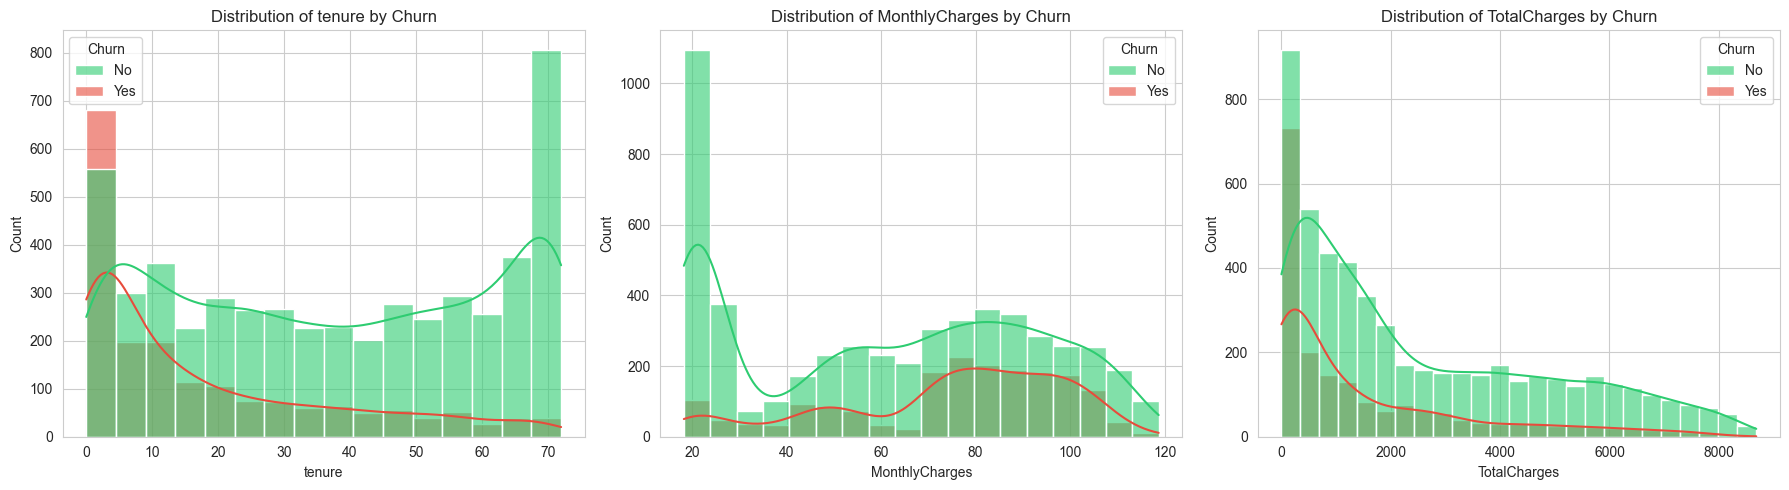

In [12]:
sns.set_style('whitegrid')

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Churn', 
        kde=True, 
        ax=axes[idx],
        palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
        alpha=0.6
    )
    axes[idx].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()
plt.show()

### Numerical features: key insights

**tenure:**
- New customers (tenure 0-5 months) churn at very high rates.
- Long-term customers (tenure >60 months) rarely churn - strong loyalty signal.
- **Insight:** First 6 months are critical for retention.

**MonthlyCharges:**
- Customers with low monthly bills (~\$20) almost never churn — likely loyal 
  basic-plan customers.
- Churn rate peaks around \$70-100/month — expensive plans see more departures.
- **Insight:** Pricing or value-for-money issues with premium customers.
  
**TotalCharges:**
- Strongly correlated with tenure (longer tenure = higher total charges).
- Churners have low TotalCharges, mostly because they leave early.
- **Insight:** May provide redundant info given `tenure`. Will assess via 
  correlation analysis.

## 6. Categorical Features: Churn Rate by Category

Now let's look at categorical features. Instead of histograms, we'll plot the 
**churn rate** (percentage) within each category. This shows which customer 
segments are most likely to leave.

C:\Users\Fanto\AppData\Local\Temp\ipykernel_7236\3327591402.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


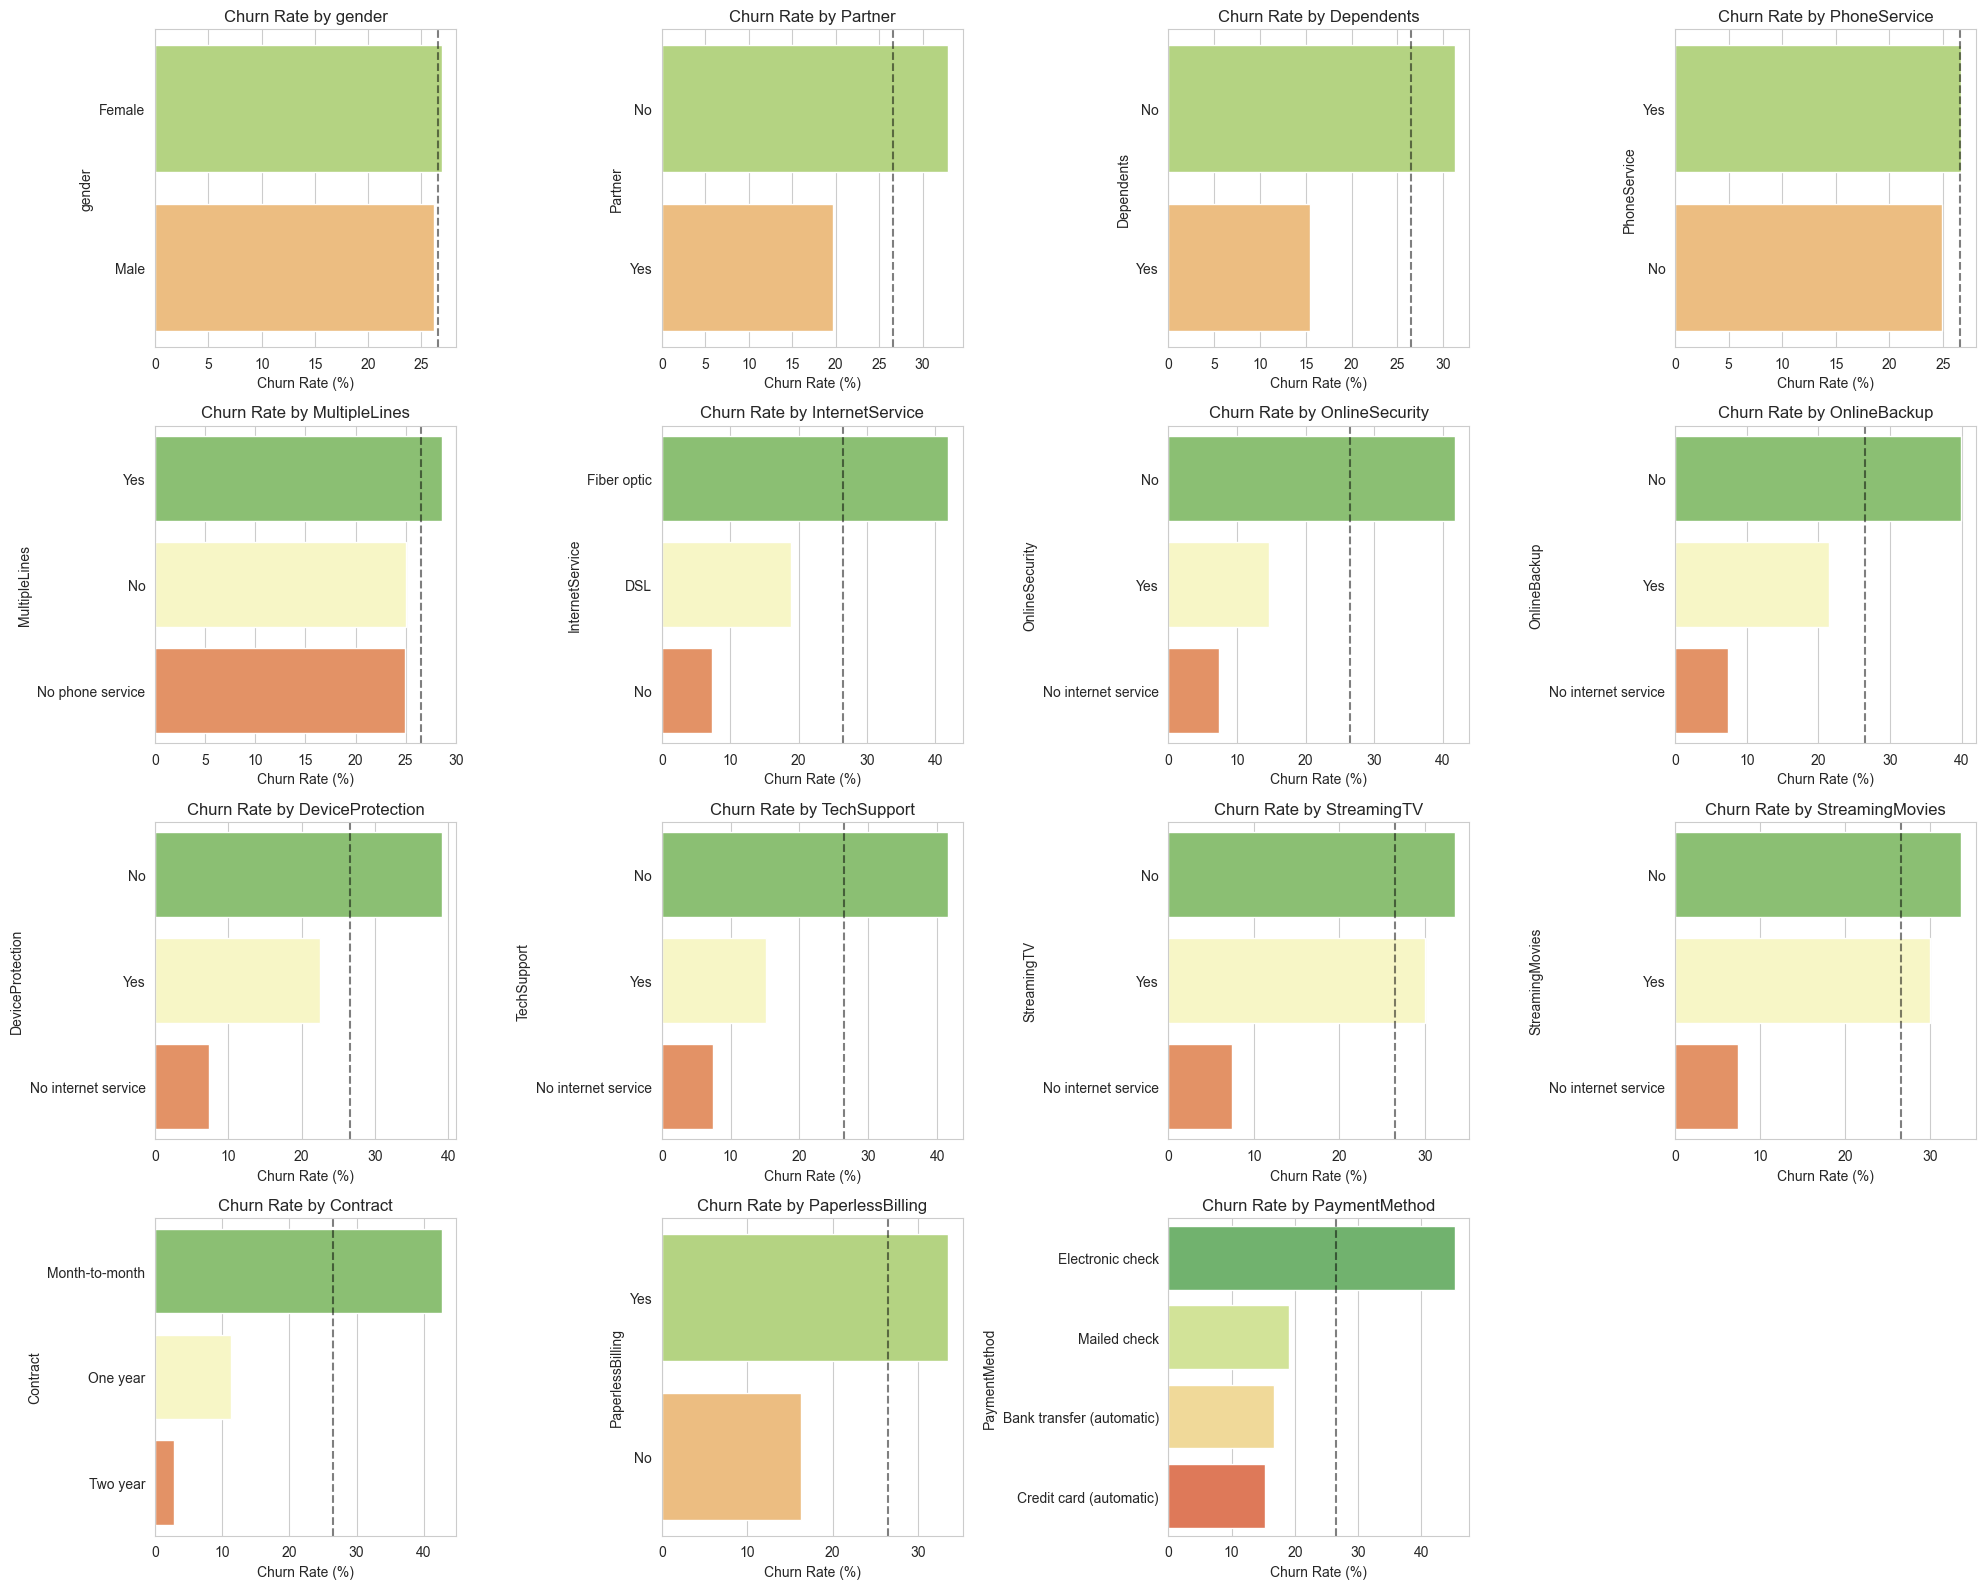

In [13]:
# Identify categorical columns (excluding customerID and target)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Plot churn rate per category
n_cols = 4
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    sns.barplot(
        x=churn_rate.values, 
        y=churn_rate.index, 
        ax=axes[idx],
        palette='RdYlGn_r',
        hue=churn_rate.index,
        legend=False
    )
    axes[idx].set_title(f'Churn Rate by {col}')
    axes[idx].set_xlabel('Churn Rate (%)')
    axes[idx].axvline(26.54, color='black', linestyle='--', alpha=0.5, label='Avg')

# Hide unused subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Categorical features: key insights

**🔥 Strongest predictors of churn:**

1. **Contract type** — *the single most important feature*:
   - Month-to-month: ~43% churn
   - One year: ~10%
   - Two year: ~3%
   - Customers on short contracts churn ~14x more than long contracts.

2. **InternetService**:
   - Fiber optic: ~42% churn (counterintuitive — premium product, high churn)
   - DSL: ~19%
   - No internet: ~7%
   - Suggests quality or pricing issues with fiber.

3. **PaymentMethod**:
   - Electronic check: ~45% churn
   - Other methods: ~15-18%
   - Auto-payment methods correlate with retention.

4. **Add-on services** (OnlineSecurity, TechSupport, DeviceProtection, OnlineBackup):
   - Customers WITHOUT these add-ons churn 2-3x more.
   - Each additional service increases customer "stickiness".

**⚪ Non-predictive features:**
- **gender** — male and female churn at nearly identical rates (~27%). Could 
  be dropped in feature engineering.
- **PhoneService** — barely above/below average.

**Business takeaway:** A high-risk customer profile would be: month-to-month 
contract, fiber optic, electronic check payment, no add-on services. The retention 
team should target this segment first.

## 7. Correlation Heatmap (Numerical Features)

Quick check for correlations between numerical features to spot redundancy.

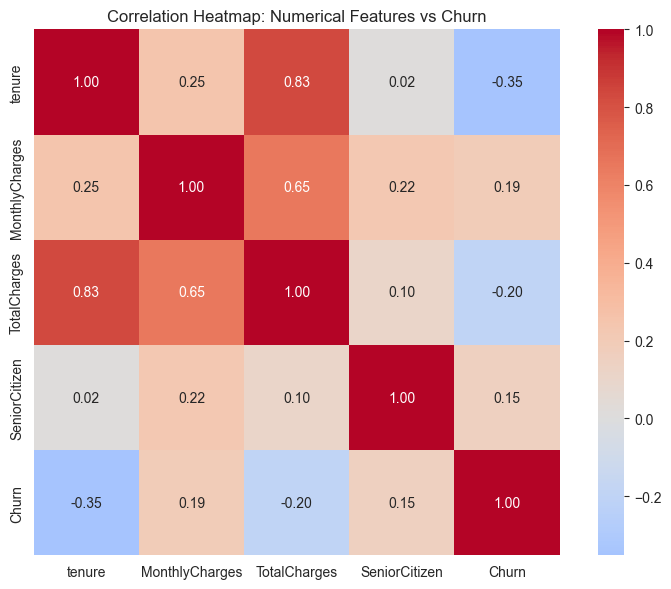

In [14]:
# Encode Churn as 0/1 for correlation
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
df_corr['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr.corr(), 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    fmt='.2f',
    square=True
)
plt.title('Correlation Heatmap: Numerical Features vs Churn')
plt.tight_layout()
plt.show()

### Correlation insights

- **tenure ↔ TotalCharges = 0.83** — strong correlation, as expected. 
  TotalCharges is roughly tenure × MonthlyCharges. We may drop `TotalCharges` 
  later to avoid multicollinearity in linear models (Logistic Regression).
- **tenure ↔ Churn = -0.35** — strongest negative correlation. Longer tenure 
  means lower churn risk.
- **MonthlyCharges ↔ Churn = 0.19** — weak but positive. Higher bills 
  slightly correlate with churn (consistent with the histogram showing 
  premium customers churning more).
- **SeniorCitizen** correlations are weak across the board (max 0.22).